Loaded 119,390 rows x 32 columns



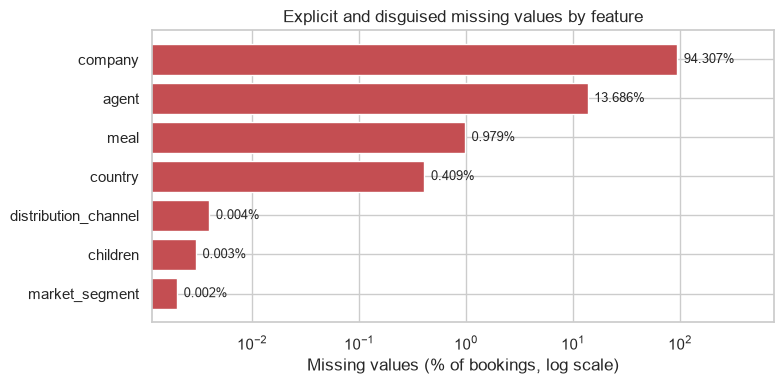

Missing value analysis:
             Feature Missing (NaN) Placeholder ('Undefined') Total missing  Missing (%)  Cancel rate if missing (%)  Cancel rate if present (%)
             company       112,593                         0       112,593       94.307                       38.22                       17.52
               agent        16,340                         0        16,340       13.686                       24.66                       39.00
                meal             0                     1,169         1,169        0.979                       24.47                       37.17
             country           488                         0           488        0.409                       13.73                       37.14
distribution_channel             0                         5             5        0.004                       80.00                       37.04
            children             4                         0             4        0.003                      100

In [1]:
# Cell 1: Setup and missing value analysis (Table 3.1, Figure 3.1)
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_RAW = ROOT / "data" / "raw" / "hotels.csv"
FIG_DIR = ROOT / "figures"
TAB_DIR = ROOT / "tables"
RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

df = pd.read_csv(DATA_RAW)
n = len(df)
print(f"Loaded {n:,} rows x {df.shape[1]} columns\n")

# Explicit (NaN) and disguised ('Undefined') missing values
rows = []
for col in df.columns:
    miss_mask = df[col].isna() | df[col].astype(str).eq("Undefined")
    n_nan = int(df[col].isna().sum())
    n_undef = int(miss_mask.sum()) - n_nan
    total = n_nan + n_undef
    if total == 0:
        continue
    rows.append({
        "Feature": col,
        "Missing (NaN)": n_nan,
        "Placeholder ('Undefined')": n_undef,
        "Total missing": total,
        "Missing (%)": round(total / n * 100, 3),
        "Cancel rate if missing (%)": round(df.loc[miss_mask, "is_canceled"].mean() * 100, 2),
        "Cancel rate if present (%)": round(df.loc[~miss_mask, "is_canceled"].mean() * 100, 2),
    })

missing = pd.DataFrame(rows).sort_values("Missing (%)", ascending=False)

# Figure 3.1: missing percentage per feature (log scale so small values stay visible)
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(missing["Feature"][::-1], missing["Missing (%)"][::-1], color="#C44E52")
for bar, pct in zip(bars, missing["Missing (%)"][::-1]):
    ax.text(bar.get_width() * 1.15, bar.get_y() + bar.get_height() / 2,
            f"{pct:.3f}%", va="center", fontsize=9)
ax.set_xscale("log")
ax.set_xlabel("Missing values (% of bookings, log scale)")
ax.set_title("Explicit and disguised missing values by feature")
ax.set_xlim(right=missing["Missing (%)"].max() * 8)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig3.1_missing_values.png", dpi=300)
plt.show()

# Table 3.1: formatted for the report
table_3_1 = missing.copy()
for c in ["Missing (NaN)", "Placeholder ('Undefined')", "Total missing"]:
    table_3_1[c] = table_3_1[c].map("{:,}".format)
table_3_1.to_csv(TAB_DIR / "table3.1_missing_values.csv", index=False)

print("Missing value analysis:")
print(table_3_1.to_string(index=False))

both_missing = int((df["agent"].isna() & df["company"].isna()).sum())
print(f"\nBookings with BOTH agent and company missing: {both_missing:,} ({both_missing / n * 100:.2f}%)")

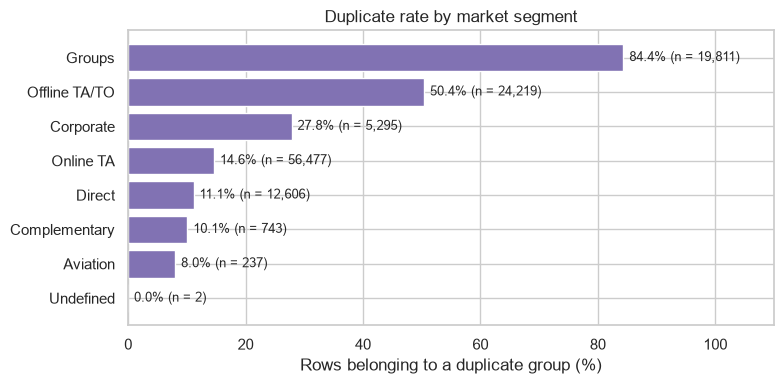

Duplicate analysis:
                                                            Check          Result
                              Exact duplicate rows (extra copies) 31,994 (26.80%)
                              Rows belonging to a duplicate group 40,165 (33.64%)
                                       Number of duplicate groups           8,171
                         Largest duplicate group (identical rows)             180
                                Cancellation rate of extra copies          63.13%
                       Cancellation rate of never-duplicated rows          26.22%
Test rows with an identical copy in training (modelling features)  7,845 (32.85%)
                                  Random Forest F1: all test rows          0.8527
                     Random Forest F1: test rows seen in training          0.9830
                     Random Forest F1: genuinely unseen test rows          0.7024

Duplicate rate by market segment (%):
                bookings  duplicate_rat

In [2]:
# Cell 2: Duplicate records (Table 3.2, Figure 3.2)
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

# 1. Describe the duplicates
dup_extra = df.duplicated(keep="first")      # extra copies beyond the first
dup_any = df.duplicated(keep=False)          # every row that belongs to a duplicate group
row_counts = df.value_counts(dropna=False)
groups = row_counts[row_counts > 1]

# 2. Duplicate rate by market segment (Figure 3.2)
seg = (df.assign(dup=dup_any)
         .groupby("market_segment")
         .agg(bookings=("dup", "size"), duplicate_rate=("dup", "mean"))
         .sort_values("duplicate_rate", ascending=False))
seg["duplicate_rate"] *= 100

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(seg.index[::-1], seg["duplicate_rate"][::-1], color="#8172B3")
for i, (rate, cnt) in enumerate(zip(seg["duplicate_rate"][::-1], seg["bookings"][::-1])):
    ax.text(rate + 1, i, f"{rate:.1f}% (n = {cnt:,})", va="center", fontsize=9)
ax.set_xlabel("Rows belonging to a duplicate group (%)")
ax.set_title("Duplicate rate by market segment")
ax.set_xlim(0, 110)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig3.2_duplicates_by_segment.png", dpi=300)
plt.show()

# 3. Train/test overlap using the same minimal preparation and split as Task 2
DROP = ["reservation_status", "reservation_status_date", "assigned_room_type", "company"]
X = df.drop(columns=DROP + ["is_canceled"]).copy()
y = df["is_canceled"]
X["agent"] = X["agent"].map(lambda v: "none" if pd.isna(v) else str(int(v)))
X["children"] = X["children"].fillna(0)
X["country"] = X["country"].fillna("Unknown")
cat_cols = X.select_dtypes(exclude="number").columns.tolist()
num_cols = X.select_dtypes(include="number").columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

train_keys = set(pd.util.hash_pandas_object(X_train, index=False))
seen = pd.util.hash_pandas_object(X_test, index=False).isin(train_keys).values

# 4. Random Forest F1 on seen vs unseen test bookings
prep = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=0.005), cat_cols),
])
rf = Pipeline([("prep", prep),
               ("model", RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                                random_state=RANDOM_STATE))])
rf.fit(X_train, y_train)
pred = rf.predict(X_test)
f1_all = f1_score(y_test, pred)
f1_seen = f1_score(y_test[seen], pred[seen])
f1_unseen = f1_score(y_test[~seen], pred[~seen])

# Table 3.2
table_3_2 = pd.DataFrame([
    ("Exact duplicate rows (extra copies)", f"{int(dup_extra.sum()):,} ({dup_extra.mean()*100:.2f}%)"),
    ("Rows belonging to a duplicate group", f"{int(dup_any.sum()):,} ({dup_any.mean()*100:.2f}%)"),
    ("Number of duplicate groups", f"{len(groups):,}"),
    ("Largest duplicate group (identical rows)", f"{int(groups.max()):,}"),
    ("Cancellation rate of extra copies", f"{df.loc[dup_extra, 'is_canceled'].mean()*100:.2f}%"),
    ("Cancellation rate of never-duplicated rows", f"{df.loc[~dup_any, 'is_canceled'].mean()*100:.2f}%"),
    ("Test rows with an identical copy in training (modelling features)", f"{int(seen.sum()):,} ({seen.mean()*100:.2f}%)"),
    ("Random Forest F1: all test rows", f"{f1_all:.4f}"),
    ("Random Forest F1: test rows seen in training", f"{f1_seen:.4f}"),
    ("Random Forest F1: genuinely unseen test rows", f"{f1_unseen:.4f}"),
], columns=["Check", "Result"])
table_3_2.to_csv(TAB_DIR / "table3.2_duplicates.csv", index=False)

print("Duplicate analysis:")
print(table_3_2.to_string(index=False))
print("\nDuplicate rate by market segment (%):")
print(seg.round(2).to_string())

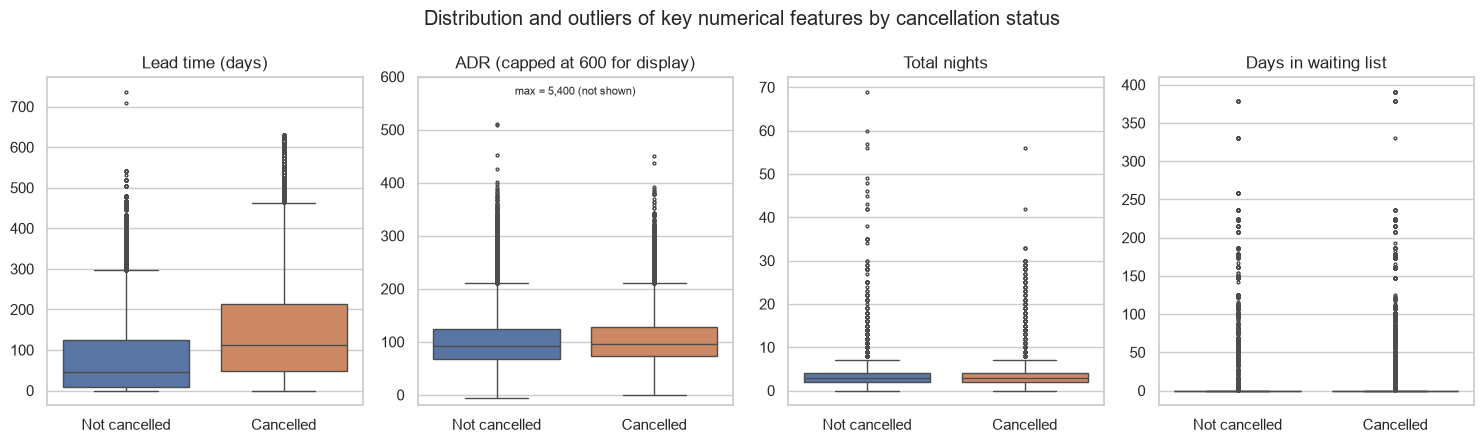

IQR outlier analysis:
                       Feature   Min    Q1  Median    Q3    Max    IQR  Upper fence IQR outliers  Outliers (%)  Cancel rate of outliers (%)
                     lead_time  0.00 18.00   69.00 160.0  737.0 142.00       373.00        3,005          2.52                        66.69
       stays_in_weekend_nights  0.00  0.00    1.00   2.0   19.0   2.00         5.00          265          0.22                        55.09
          stays_in_week_nights  0.00  1.00    2.00   3.0   50.0   2.00         6.00        3,354          2.81                        34.68
                        adults  0.00  2.00    2.00   2.0   55.0   0.00         2.00       29,710         24.88                        30.18
                      children  0.00  0.00    0.00   0.0   10.0   0.00         0.00        8,590          7.19                        36.39
                        babies  0.00  0.00    0.00   0.0   10.0   0.00         0.00          917          0.77                        18.2

In [3]:
# Cell 3: Outlier analysis (Table 3.3, Figure 3.3)
out_cols = ["lead_time", "stays_in_weekend_nights", "stays_in_week_nights", "adults",
            "children", "babies", "previous_cancellations", "previous_bookings_not_canceled",
            "booking_changes", "days_in_waiting_list", "adr",
            "required_car_parking_spaces", "total_of_special_requests"]

rows = []
for col in out_cols:
    s = df[col].dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (df[col] < lower) | (df[col] > upper)
    rows.append({
        "Feature": col,
        "Min": round(s.min(), 2),
        "Q1": round(q1, 2),
        "Median": round(s.median(), 2),
        "Q3": round(q3, 2),
        "Max": round(s.max(), 2),
        "IQR": round(iqr, 2),
        "Upper fence": round(upper, 2),
        "IQR outliers": f"{int(mask.sum()):,}",
        "Outliers (%)": round(mask.mean() * 100, 2),
        "Cancel rate of outliers (%)": round(df.loc[mask, "is_canceled"].mean() * 100, 2) if mask.any() else np.nan,
    })

table_3_3 = pd.DataFrame(rows)
table_3_3.to_csv(TAB_DIR / "table3.3_outliers_iqr.csv", index=False)

# Figure 3.3: boxplots split by cancellation status
plot_df = df.assign(total_nights=df["stays_in_weekend_nights"] + df["stays_in_week_nights"],
                    status=df["is_canceled"].map({0: "Not cancelled", 1: "Cancelled"}))
panels = [("lead_time", "Lead time (days)", None),
          ("adr", "ADR (capped at 600 for display)", (-20, 600)),
          ("total_nights", "Total nights", None),
          ("days_in_waiting_list", "Days in waiting list", None)]

fig, axes = plt.subplots(1, 4, figsize=(15, 4.5))
for ax, (col, label, ylim) in zip(axes, panels):
    sns.boxplot(data=plot_df, x="status", y=col, hue="status", ax=ax,
                palette={"Not cancelled": "#4C72B0", "Cancelled": "#DD8452"},
                legend=False, fliersize=2)
    ax.set_title(label)
    ax.set_xlabel("")
    ax.set_ylabel("")
    if ylim:
        ax.set_ylim(*ylim)
axes[1].text(0.5, 0.97, f"max = {df['adr'].max():,.0f} (not shown)",
             transform=axes[1].transAxes, ha="center", va="top", fontsize=8)
fig.suptitle("Distribution and outliers of key numerical features by cancellation status")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig3.3_outlier_boxplots.png", dpi=300)
plt.show()

print("IQR outlier analysis:")
print(table_3_3.to_string(index=False))
print(f"\nOverall cancellation rate for comparison: {df['is_canceled'].mean()*100:.2f}%")

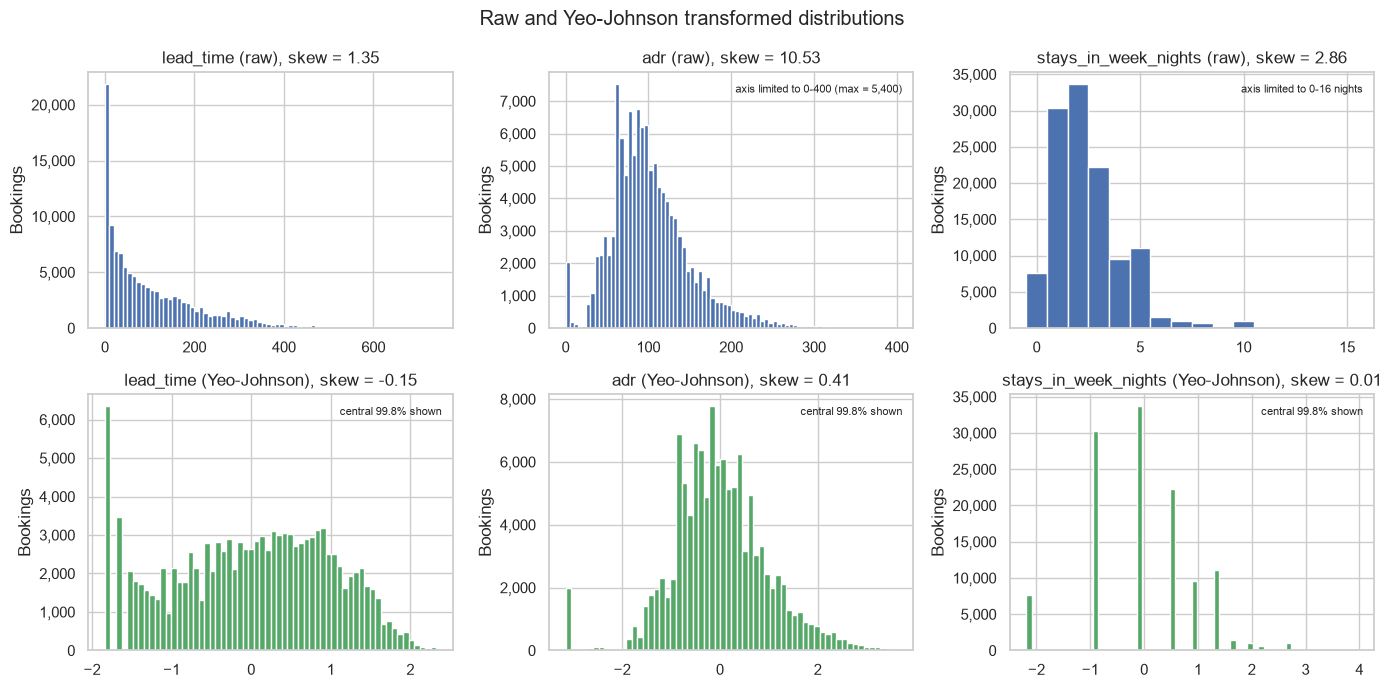

Skewness analysis:
                       Feature   Mean    Std  Skewness  Kurtosis  Skewness after log1p  Skewness after Yeo-Johnson
                        babies   0.01   0.10     24.65   1633.88                 11.92                       11.28
        previous_cancellations   0.09   0.84     24.46    674.05                  7.35                        3.93
previous_bookings_not_canceled   0.14   1.50     23.54    767.21                  8.17                        5.48
                        adults   1.86   0.58     18.32   1352.06                 -1.03                        0.53
          days_in_waiting_list   2.32  17.59     11.94    186.79                  5.75                        5.41
                           adr 101.83  50.54     10.53   1013.15                 -3.74                        0.41
               booking_changes   0.22   0.65      6.00     79.39                  2.57                        1.95
   required_car_parking_spaces   0.06   0.25      4.16     30

In [8]:
# Cell 4: Distributions and skewness (Table 3.4, Table 3.5, Figure 3.4)
from scipy.stats import skew, kurtosis
from sklearn.preprocessing import PowerTransformer

# Table 3.4: skewness before and after transformation (analysis only, not the Task 4 pipeline)
rows = []
for col in out_cols:
    s = df[col].dropna().astype(float)
    log_s = np.log1p(s.clip(lower=0))
    yj_s = PowerTransformer(method="yeo-johnson").fit_transform(s.to_frame()).ravel()
    rows.append({
        "Feature": col,
        "Mean": round(s.mean(), 2),
        "Std": round(s.std(), 2),
        "Skewness": round(skew(s), 2),
        "Kurtosis": round(kurtosis(s), 2),
        "Skewness after log1p": round(skew(log_s), 2),
        "Skewness after Yeo-Johnson": round(skew(yj_s), 2),
    })
table_3_4 = pd.DataFrame(rows).sort_values("Skewness", ascending=False, key=abs)
table_3_4.to_csv(TAB_DIR / "table3.4_skewness.csv", index=False)

# Figure 3.4: raw vs Yeo-Johnson distributions for three key features
from matplotlib.ticker import StrMethodFormatter

fig_specs = [
    ("lead_time", np.linspace(0, 740, 75), None),
    ("adr", np.linspace(0, 400, 81), "axis limited to 0-400 (max = 5,400)"),
    ("stays_in_week_nights", np.arange(-0.5, 16.5, 1), "axis limited to 0-16 nights"),
]
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for i, (col, raw_bins, note) in enumerate(fig_specs):
    s = df[col].dropna().astype(float)
    yj = PowerTransformer(method="yeo-johnson").fit_transform(s.to_frame()).ravel()

    # Raw distribution with bins matched to the displayed range
    axes[0, i].hist(s, bins=raw_bins, color="#4C72B0")
    axes[0, i].set_title(f"{col} (raw), skew = {skew(s):.2f}")
    if note:
        axes[0, i].text(0.97, 0.95, note, transform=axes[0, i].transAxes,
                        ha="right", va="top", fontsize=8)

    # Transformed distribution showing the central 99.8% of values
    lo, hi = np.percentile(yj, [0.1, 99.9])
    axes[1, i].hist(yj, bins=np.linspace(lo, hi, 61), color="#55A868")
    axes[1, i].set_title(f"{col} (Yeo-Johnson), skew = {skew(yj):.2f}")
    axes[1, i].text(0.97, 0.95, "central 99.8% shown", transform=axes[1, i].transAxes,
                    ha="right", va="top", fontsize=8)

for ax in axes.flat:
    ax.set_ylabel("Bookings")
    ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
fig.suptitle("Raw and Yeo-Johnson transformed distributions")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig3.4_distributions_skewness.png", dpi=300)
plt.show()

# Table 3.5: categorical distributions (dominance of the most common level)
cat_cols_all = ["hotel", "arrival_date_month", "meal", "country", "market_segment",
                "distribution_channel", "reserved_room_type", "deposit_type",
                "customer_type", "is_repeated_guest"]
rows = []
for col in cat_cols_all:
    vc = df[col].value_counts(normalize=True, dropna=False)
    rows.append({
        "Feature": col,
        "Levels": df[col].nunique(dropna=True),
        "Most common level": str(vc.index[0]),
        "Share of most common (%)": round(vc.iloc[0] * 100, 2),
        "Levels under 1% share": int((vc < 0.01).sum()),
    })
table_3_5 = pd.DataFrame(rows).sort_values("Share of most common (%)", ascending=False)
table_3_5.to_csv(TAB_DIR / "table3.5_categorical_distribution.csv", index=False)

print("Skewness analysis:")
print(table_3_4.to_string(index=False))
print("\nCategorical distribution:")
print(table_3_5.to_string(index=False))

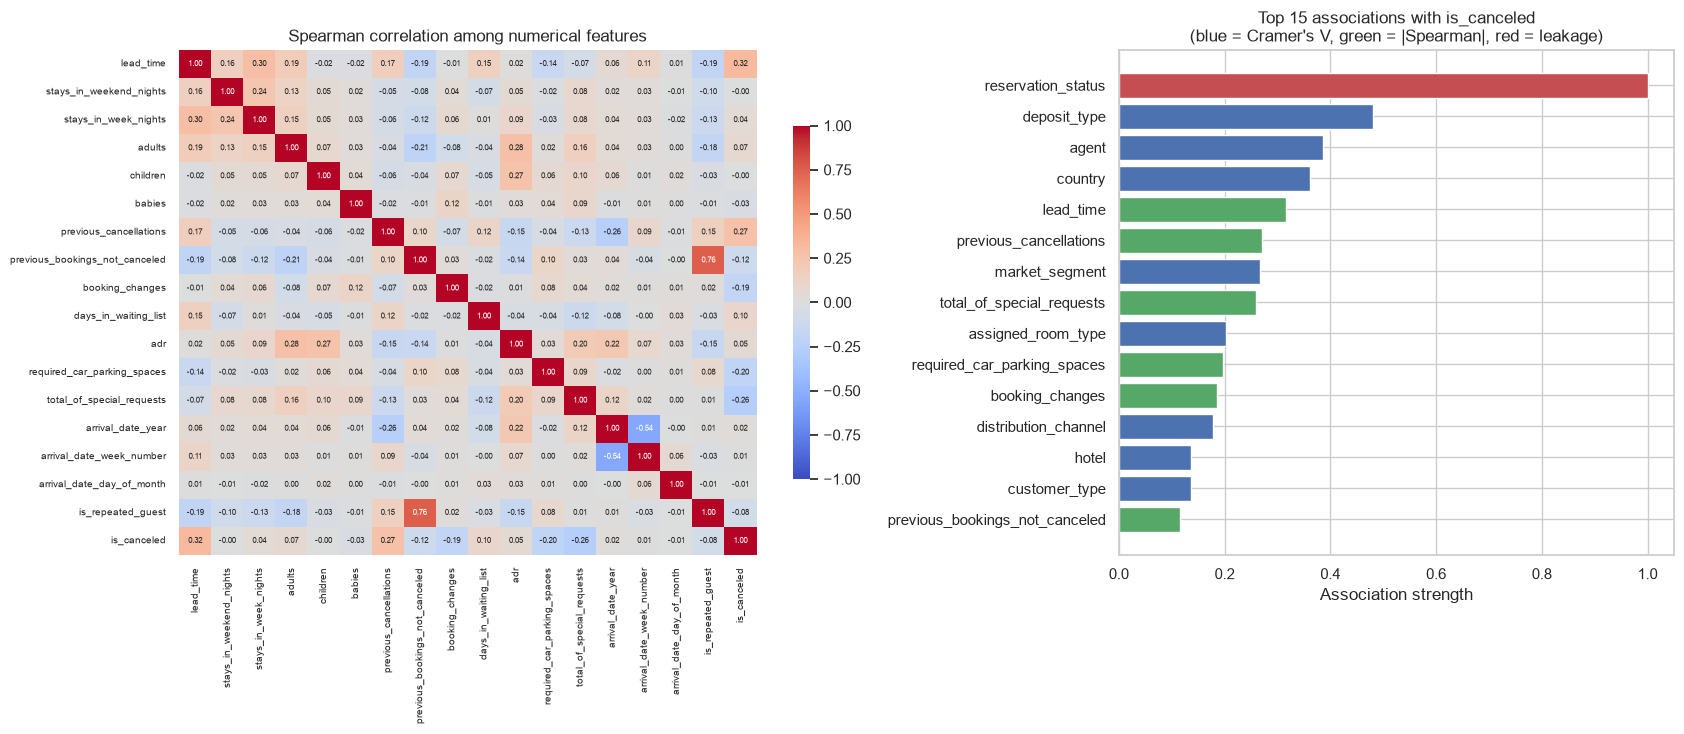

Association with the target (top 15):
                       Feature        Measure  Association with is_canceled
            reservation_status     Cramer's V                        1.0000
                  deposit_type     Cramer's V                        0.4815
                         agent     Cramer's V                        0.3860
                       country     Cramer's V                        0.3611
                     lead_time |Spearman rho|                        0.3166
        previous_cancellations |Spearman rho|                        0.2702
                market_segment     Cramer's V                        0.2668
     total_of_special_requests |Spearman rho|                        0.2585
            assigned_room_type     Cramer's V                        0.2030
   required_car_parking_spaces |Spearman rho|                        0.1974
               booking_changes |Spearman rho|                        0.1851
          distribution_channel     Cramer's V     

In [5]:
# Cell 5: Correlation and association (Table 3.6, Table 3.7, Figure 3.5)
from itertools import combinations
from scipy.stats import chi2_contingency


def cramers_v(a, b):
    """Cramer's V association between two categorical series (0 = none, 1 = perfect)."""
    ct = pd.crosstab(a, b)
    chi2 = chi2_contingency(ct, correction=False)[0]
    r, k = ct.shape
    return float(np.sqrt(chi2 / (ct.values.sum() * (min(r, k) - 1))))


num_list = out_cols + ["arrival_date_year", "arrival_date_week_number",
                       "arrival_date_day_of_month", "is_repeated_guest"]
cat_list = ["hotel", "arrival_date_month", "meal", "country", "market_segment",
            "distribution_channel", "reserved_room_type", "assigned_room_type",
            "deposit_type", "customer_type", "agent", "reservation_status"]

cat_df = df[cat_list].copy()
cat_df["agent"] = cat_df["agent"].map(lambda v: "none" if pd.isna(v) else str(int(v)))
cat_df = cat_df.fillna("Missing").astype(str)

# Spearman correlation matrix for numerical features (plus the target)
spearman = df[num_list + ["is_canceled"]].corr(method="spearman")

# Table 3.6: association of every feature with the target
target_rows = [{"Feature": c, "Measure": "|Spearman rho|",
                "Association with is_canceled": round(abs(spearman.loc[c, "is_canceled"]), 4)}
               for c in num_list]
target_rows += [{"Feature": c, "Measure": "Cramer's V",
                 "Association with is_canceled": round(cramers_v(cat_df[c], df["is_canceled"]), 4)}
                for c in cat_list]
table_3_6 = (pd.DataFrame(target_rows)
               .sort_values("Association with is_canceled", ascending=False)
               .reset_index(drop=True))
table_3_6.to_csv(TAB_DIR / "table3.6_target_association.csv", index=False)

# Table 3.7: redundant pairs (|rho| >= 0.4 numerical, V >= 0.5 categorical)
pair_rows = []
for a, b in combinations(num_list, 2):
    rho = spearman.loc[a, b]
    if abs(rho) >= 0.4:
        pair_rows.append({"Feature A": a, "Feature B": b, "Measure": "Spearman rho",
                          "Value": round(rho, 4)})
for a, b in combinations([c for c in cat_list if c != "reservation_status"], 2):
    v = cramers_v(cat_df[a], cat_df[b])
    if v >= 0.5:
        pair_rows.append({"Feature A": a, "Feature B": b, "Measure": "Cramer's V",
                          "Value": round(v, 4)})
table_3_7 = (pd.DataFrame(pair_rows)
               .sort_values("Value", ascending=False, key=abs)
               .reset_index(drop=True))
table_3_7.to_csv(TAB_DIR / "table3.7_redundant_pairs.csv", index=False)

# Figure 3.5: Spearman heatmap and target association ranking
fig, axes = plt.subplots(1, 2, figsize=(17, 7.5), gridspec_kw={"width_ratios": [1.3, 1]})
sns.heatmap(spearman, cmap="coolwarm", center=0, vmin=-1, vmax=1, annot=True, fmt=".2f",
            annot_kws={"size": 6}, cbar_kws={"shrink": 0.7}, ax=axes[0])
axes[0].set_title("Spearman correlation among numerical features")
axes[0].tick_params(labelsize=7)

top = table_3_6.head(15).iloc[::-1]
colors = ["#C44E52" if f == "reservation_status" else
          ("#4C72B0" if m == "Cramer's V" else "#55A868")
          for f, m in zip(top["Feature"], top["Measure"])]
axes[1].barh(top["Feature"], top["Association with is_canceled"], color=colors)
axes[1].set_title("Top 15 associations with is_canceled\n"
                  "(blue = Cramer's V, green = |Spearman|, red = leakage)")
axes[1].set_xlabel("Association strength")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig3.5_correlation_association.png", dpi=300)
plt.show()

print("Association with the target (top 15):")
print(table_3_6.head(15).to_string(index=False))
print("\nRedundant feature pairs:")
print(table_3_7.to_string(index=False))

In [6]:
# Cell 6: Class imbalance under different conditions (Table 3.8)
def balance_row(label, data):
    counts = data["is_canceled"].value_counts()
    n0, n1 = int(counts.get(0, 0)), int(counts.get(1, 0))
    return {
        "Subset": label,
        "Bookings": f"{n0 + n1:,}",
        "Not cancelled": f"{n0:,}",
        "Cancelled": f"{n1:,}",
        "Cancelled (%)": round(n1 / (n0 + n1) * 100, 2),
        "Imbalance ratio": f"{max(n0, n1) / max(min(n0, n1), 1):.2f}:1",
    }

rows = [balance_row("Full dataset", df),
        balance_row("After removing exact duplicates", df.drop_duplicates())]
for col in ["hotel", "deposit_type"]:
    for level, grp in df.groupby(col):
        rows.append(balance_row(f"{col} = {level}", grp))

table_3_8 = pd.DataFrame(rows)
table_3_8.to_csv(TAB_DIR / "table3.8_class_imbalance.csv", index=False)

print("Class balance under different conditions:")
print(table_3_8.to_string(index=False))

print("\nCancellation rate by market segment (%):")
seg_rate = df.groupby("market_segment")["is_canceled"].agg(["size", "mean"])
seg_rate["mean"] = (seg_rate["mean"] * 100).round(2)
print(seg_rate.rename(columns={"size": "Bookings", "mean": "Cancelled (%)"})
              .sort_values("Cancelled (%)", ascending=False).to_string())

Class balance under different conditions:
                         Subset Bookings Not cancelled Cancelled  Cancelled (%) Imbalance ratio
                   Full dataset  119,390        75,166    44,224          37.04          1.70:1
After removing exact duplicates   87,396        63,371    24,025          27.49          2.64:1
             hotel = City Hotel   79,330        46,228    33,102          41.73          1.40:1
           hotel = Resort Hotel   40,060        28,938    11,122          27.76          2.60:1
      deposit_type = No Deposit  104,641        74,947    29,694          28.38          2.52:1
      deposit_type = Non Refund   14,587            93    14,494          99.36        155.85:1
      deposit_type = Refundable      162           126        36          22.22          3.50:1

Cancellation rate by market segment (%):
                Bookings  Cancelled (%)
market_segment                         
Undefined              2         100.00
Groups             19811    

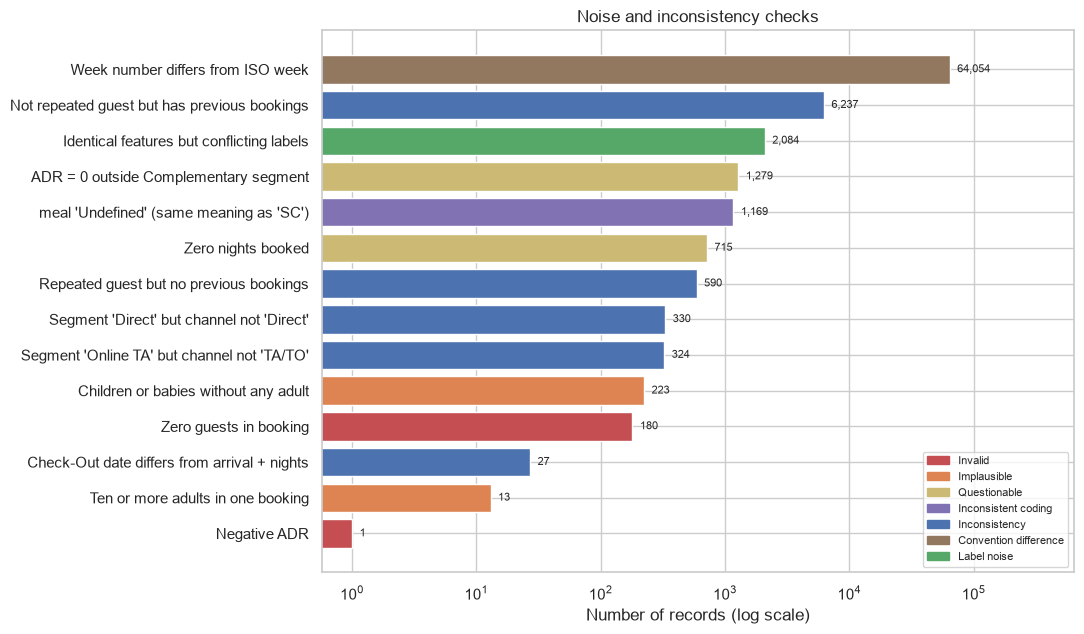

Noise and inconsistency checks:
                                       Check              Category Records  Records (%)  Cancel rate (%)
     meal 'Undefined' (same meaning as 'SC')   Inconsistent coding   1,169        0.979            24.47
                      Zero guests in booking               Invalid     180        0.151            13.89
        Children or babies without any adult           Implausible     223        0.187            37.67
           Ten or more adults in one booking           Implausible      13        0.011           100.00
                          Zero nights booked          Questionable     715        0.599             4.90
                                Negative ADR               Invalid       1        0.001             0.00
       ADR = 0 outside Complementary segment          Questionable   1,279        1.071             9.46
Not repeated guest but has previous bookings         Inconsistency   6,237        5.224            88.06
     Repeated guest but

In [9]:
# Cell 7: Noise and data inconsistency (Table 3.9, Figure 3.6)
month_map = {m: i for i, m in enumerate(
    ["January", "February", "March", "April", "May", "June", "July",
     "August", "September", "October", "November", "December"], start=1)}
arrival = pd.to_datetime(pd.DataFrame({"year": df["arrival_date_year"],
                                       "month": df["arrival_date_month"].map(month_map),
                                       "day": df["arrival_date_day_of_month"]}))
status_date = pd.to_datetime(df["reservation_status_date"])
nights = df["stays_in_weekend_nights"] + df["stays_in_week_nights"]
kids = df["children"].fillna(0) + df["babies"]
guests = df["adults"] + kids
prev_total = df["previous_cancellations"] + df["previous_bookings_not_canceled"]
iso_week = arrival.dt.isocalendar().week.astype(int).values
ms, dc, rs = df["market_segment"], df["distribution_channel"], df["reservation_status"]

# Label noise: identical modelling features (X from Cell 2) but different outcomes
feat_key = pd.util.hash_pandas_object(X, index=False)
label_variety = df["is_canceled"].groupby(feat_key.values).nunique()
conflict = feat_key.isin(label_variety.index[label_variety > 1]).values

checks = [
    ("meal 'Undefined' (same meaning as 'SC')", "Inconsistent coding", df["meal"] == "Undefined"),
    ("Zero guests in booking", "Invalid", guests == 0),
    ("Children or babies without any adult", "Implausible", (df["adults"] == 0) & (kids > 0)),
    ("Ten or more adults in one booking", "Implausible", df["adults"] >= 10),
    ("Zero nights booked", "Questionable", nights == 0),
    ("Negative ADR", "Invalid", df["adr"] < 0),
    ("ADR = 0 outside Complementary segment", "Questionable", (df["adr"] == 0) & (ms != "Complementary")),
    ("Not repeated guest but has previous bookings", "Inconsistency", (df["is_repeated_guest"] == 0) & (prev_total > 0)),
    ("Repeated guest but no previous bookings", "Inconsistency", (df["is_repeated_guest"] == 1) & (prev_total == 0)),
    ("Segment 'Direct' but channel not 'Direct'", "Inconsistency", (ms == "Direct") & (dc != "Direct")),
    ("Segment 'Online TA' but channel not 'TA/TO'", "Inconsistency", (ms == "Online TA") & (dc != "TA/TO")),
    ("Week number differs from ISO week", "Convention difference", df["arrival_date_week_number"].values != iso_week),
    ("Check-Out date differs from arrival + nights", "Inconsistency", (rs == "Check-Out") & (status_date != arrival + pd.to_timedelta(nights, unit="D"))),
    ("Cancellation recorded after arrival date", "Inconsistency", (rs == "Canceled") & (status_date > arrival)),
    ("Identical features but conflicting labels", "Label noise", conflict),
]

rows = []
for name, category, mask in checks:
    mask = np.asarray(mask)
    rows.append({
        "Check": name,
        "Category": category,
        "Records": int(mask.sum()),
        "Records (%)": round(mask.mean() * 100, 3),
        "Cancel rate (%)": round(df.loc[mask, "is_canceled"].mean() * 100, 2) if mask.any() else np.nan,
    })
issues = pd.DataFrame(rows)

# Figure 3.6: record counts per check (log scale), one colour per category
palette = {"Invalid": "#C44E52", "Implausible": "#DD8452", "Questionable": "#CCB974",
           "Inconsistent coding": "#8172B3", "Inconsistency": "#4C72B0",
           "Convention difference": "#937860", "Label noise": "#55A868"}
plot_issues = issues[issues["Records"] > 0].sort_values("Records")
fig, ax = plt.subplots(figsize=(11, 6.5))
ax.barh(plot_issues["Check"], plot_issues["Records"],
        color=[palette[c] for c in plot_issues["Category"]])
for i, cnt in enumerate(plot_issues["Records"]):
    ax.text(cnt * 1.15, i, f"{cnt:,}", va="center", fontsize=8)
ax.set_xscale("log")
ax.set_xlabel("Number of records (log scale)")
ax.set_title("Noise and inconsistency checks")
present = [c for c in palette if c in set(plot_issues["Category"])]
handles = [plt.Rectangle((0, 0), 1, 1, color=palette[c]) for c in present]
ax.legend(handles, present, fontsize=8, loc="lower right")
ax.set_xlim(right=plot_issues["Records"].max() * 10)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig3.6_noise_inconsistency.png", dpi=300)
plt.show()

table_3_9 = issues.copy()
table_3_9["Records"] = table_3_9["Records"].map("{:,}".format)
table_3_9.to_csv(TAB_DIR / "table3.9_noise_inconsistency.csv", index=False)

print("Noise and inconsistency checks:")
print(table_3_9.to_string(index=False))
print(f"\nOverall cancellation rate for comparison: {df['is_canceled'].mean()*100:.2f}%")